In [1]:
import pandas as pd

df = pd.read_csv("BigBasket_Products.csv")
df.head()

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ..."
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m..."
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...


Remove Duplicate Rows

In [2]:
df = df.drop_duplicates()

Clean Column Names

In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

Check Missing Values

In [4]:
df.isnull().sum()

index              0
product            1
category           0
sub_category       0
brand              1
sale_price         0
market_price       0
type               0
rating          8626
description      115
dtype: int64

Remove ₹ symbol and Convert Prices to Numeric

In [5]:
df['sale_price'] = df['sale_price'].replace('[₹,]', '', regex=True).astype(float)
df['market_price'] = df['market_price'].replace('[₹,]', '', regex=True).astype(float)

Create Discount Column

In [6]:
df['discount'] = df['market_price'] - df['sale_price']
df['discount_percent'] = ((df['discount'] / df['market_price']) * 100).round(2)

Remove Invalid Prices (0 or Negative)

In [7]:
df = df[df['sale_price'] > 0]
df = df[df['market_price'] > 0]

Reset Index (Important before saving)

In [8]:
df = df.reset_index(drop=True)

In [9]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 27555 entries, 0 to 27554
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   index             27555 non-null  int64  
 1   product           27554 non-null  str    
 2   category          27555 non-null  str    
 3   sub_category      27555 non-null  str    
 4   brand             27554 non-null  str    
 5   sale_price        27555 non-null  float64
 6   market_price      27555 non-null  float64
 7   type              27555 non-null  str    
 8   rating            18929 non-null  float64
 9   description       27440 non-null  str    
 10  discount          27555 non-null  float64
 11  discount_percent  27555 non-null  float64
dtypes: float64(5), int64(1), str(6)
memory usage: 2.5 MB


,index,sale_price,market_price,rating,discount,discount_percent
count,27555.00000,27555.000000,27555.000000,18929.000000,27555.000000,27555.000000
mean,13778.00000,322.514808,382.056664,3.943410,59.541857,11.824860
std,7954.58767,486.263116,581.730717,0.739063,169.715148,14.624493
min,1.00000,2.450000,3.000000,1.000000,0.000000,0.000000
25%,6889.50000,95.000000,100.000000,3.700000,0.000000,0.000000
50%,13778.00000,190.000000,220.000000,4.100000,6.000000,5.000000
75%,20666.50000,359.000000,425.000000,4.300000,51.000000,20.000000
max,27555.00000,12500.000000,12500.000000,5.000000,4320.000000,83.670000


Save Cleaned File

In [10]:
df.to_csv("bigbasket_cleaned.csv", index=False)

Q1: What is total number of products?

In [11]:
df['product'].nunique()

23540

Q2: Which category has highest number of products?

In [12]:
df['category'].value_counts().head(1)

category
Beauty & Hygiene    7867
Name: count, dtype: int64

Q3: Top 10 most expensive products?

In [13]:
df.sort_values(by='sale_price', ascending=False).head(10)

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description,discount,discount_percent
25301,25302,Bravura Clipper,"Kitchen, Garden & Pets",Pet Food & Accessories,Wahl,12500.00,12500.0,Pet Cleaning & Grooming,NaN,The bravura clipper is a must-have clipper for...,0.00,0.00
21761,21762,Pet Food - N&D Team Breeder Puppy Top Farmina,"Kitchen, Garden & Pets",Pet Food & Accessories,Farmina,10090.00,10090.0,Pet Meals & Treats,NaN,Dog Food Adult Health Nutritional Dog Food.,0.00,0.00
12669,12670,Epilator SE9-9961 Legs-Body-Face,Beauty & Hygiene,Feminine Hygiene,Braun,8184.44,10769.0,Hair Removal,NaN,This cordless epilator has a sonic exfoliation...,2584.56,24.00
23082,23083,"Gas Stove-4 Burner Royale Plus Schott Glass, B...","Kitchen, Garden & Pets",Cookware & Non Stick,Prestige,7999.00,12245.0,Gas Stove,NaN,Prestige Royale Plus Gas Stove. Add a Touch of...,4246.00,34.68
2781,2782,Extra Virgin Olive Oil,Gourmet & World Food,Oils & Vinegar,Abbies,7299.00,7299.0,Extra Virgin Olive Oil,NaN,Suitable to cook Indian meals due to its neutr...,0.00,0.00
25797,25798,"4 Burner Gas Stove - Marvel Plus Glass Tables,...","Kitchen, Garden & Pets",Cookware & Non Stick,Prestige,7270.00,9695.0,Gas Stove,NaN,Prestige Marvel Plus Gas Stove . A Smart and C...,2425.00,25.01
1056,1057,"Gas Stove-3 Burner Royale Plus Schott Glass, B...","Kitchen, Garden & Pets",Cookware & Non Stick,Prestige,6999.00,10695.0,Gas Stove,NaN,Prestige Royale Plus Gas Stove. Add a Touch of...,3696.00,34.56
6034,6035,Whey Protein Powder,Beauty & Hygiene,Health & Medicine,BTN Sports,6700.00,6700.0,Supplements & Proteins,NaN,BTN Premium Gold 100% Whey Protein contains hi...,0.00,0.00
1766,1767,Good Girl Eau De Parfum For Women,Beauty & Hygiene,Fragrances & Deos,Carolina Herrera,6660.00,7400.0,Eau De Parfum,5.0,Well behaved girls rarely make history...GOOD ...,740.00,10.00
5464,5465,Olive Oil - Extra Virgin,Gourmet & World Food,Oils & Vinegar,Colavita,6500.00,6500.0,Extra Virgin Olive Oil,NaN,Extra virgin olive oil is produced by the firs...,0.00,0.00


Q4: Average price of products?

In [14]:
df['sale_price'].mean()

np.float64(322.5148078388677)

Q5: Which brand has most products?

In [15]:
df['brand'].value_counts().head(10)

brand
Fresho              638
bb Royal            539
BB Home             428
DP                  250
Fresho Signature    171
bb Combo            168
Amul                153
INATUR              146
Himalaya            141
Dabur               138
Name: count, dtype: int64

Q6: Products with highest discount

In [16]:
df['discount'] = df['market_price'] - df['sale_price']

In [17]:
df.sort_values(by='discount', ascending=False).head(10)

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description,discount,discount_percent
21930,21931,"Premium Cloth Dryer/Drying Stand - Foldable, S...","Kitchen, Garden & Pets",Storage & Accessories,DP,4649.0,8969.0,Cloth Dryer & Iron Table,NaN,Drying clothes can be a tedious task where spa...,4320.0,48.17
23082,23083,"Gas Stove-4 Burner Royale Plus Schott Glass, B...","Kitchen, Garden & Pets",Cookware & Non Stick,Prestige,7999.0,12245.0,Gas Stove,NaN,Prestige Royale Plus Gas Stove. Add a Touch of...,4246.0,34.68
1056,1057,"Gas Stove-3 Burner Royale Plus Schott Glass, B...","Kitchen, Garden & Pets",Cookware & Non Stick,Prestige,6999.0,10695.0,Gas Stove,NaN,Prestige Royale Plus Gas Stove. Add a Touch of...,3696.0,34.56
2343,2344,Induction Base Non Stick Cookware Set With Gla...,"Kitchen, Garden & Pets",Cookware & Non Stick,Nirlon,1399.0,4999.0,Cookware Sets,3.1,Prepare healthy meal quickly and easily into N...,3600.0,72.01
8759,8760,"Dinner Set - Laser Etched, Premium Stainless S...","Kitchen, Garden & Pets",Steel Utensils,Classic Essentials,2499.0,5999.0,Plates & Tumblers,3.4,Classic Essentials Dinner Set is made from qua...,3500.0,58.34
1789,1790,Induction Base Non Stick Cookware Set With Gla...,"Kitchen, Garden & Pets",Cookware & Non Stick,Nirlon,1499.0,4999.0,Cookware Sets,3.2,Say goodbye to boring cooking sessions and tak...,3500.0,70.01
2369,2370,Olive Oil - Extra Light,Gourmet & World Food,Oils & Vinegar,BORGES,2280.0,5200.0,"Pure, Pomace Olive Oil",4.4,Borges Light Flavour Olive Oil has a very soft...,2920.0,56.15
12430,12431,Olive Oil - Extra Light,"Foodgrains, Oil & Masala",Edible Oils & Ghee,BORGES,2625.0,5500.0,Olive & Canola Oils,4.4,NaN,2875.0,52.27
13406,13407,3 Burner Gas Stove - Glass Top Manual Ignition...,"Kitchen, Garden & Pets",Cookware & Non Stick,Pigeon,2799.0,5595.0,Gas Stove,NaN,This Pigeon gas stove features a high-quality ...,2796.0,49.97
26933,26934,Starter Dry Dog Food - Ultra Premium,"Kitchen, Garden & Pets",Pet Food & Accessories,Canine Creek,4050.0,6750.0,Pet Meals & Treats,3.0,Canine Creek Ultra Premium Starter Dog Food is...,2700.0,40.00


Q7: Which category gives highest average discount?

In [18]:
df.groupby('category')['discount'].mean().sort_values(ascending=False)

category
Kitchen, Garden & Pets      152.133039
Beauty & Hygiene             74.856105
Baby Care                    61.807918
Gourmet & World Food         38.566874
Foodgrains, Oil & Masala     36.964413
Eggs, Meat & Fish            36.938000
Cleaning & Household         35.939163
Beverages                    32.474949
Bakery, Cakes & Dairy        15.078566
Fruits & Vegetables          13.544327
Snacks & Branded Foods       11.182097
Name: discount, dtype: float64

Q8: Count of products in each category

In [19]:
df['category'].value_counts()

category
Beauty & Hygiene            7867
Gourmet & World Food        4690
Kitchen, Garden & Pets      3580
Snacks & Branded Foods      2814
Foodgrains, Oil & Masala    2676
Cleaning & Household        2675
Beverages                    885
Bakery, Cakes & Dairy        851
Baby Care                    610
Fruits & Vegetables          557
Eggs, Meat & Fish            350
Name: count, dtype: int64

Q9: Cheapest 10 products

In [20]:
df.sort_values(by='sale_price').head(10)

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description,discount,discount_percent
26976,26977,Curry Leaves,Fruits & Vegetables,Herbs & Seasonings,Fresho,2.45,15.00,Indian & Exotic Herbs,NaN,"With dark green and glossy appearance, curry l...",12.55,83.67
21312,21313,Serum,Beauty & Hygiene,Hair Care,Livon,3.00,3.00,Hair Oil & Serum,2.5,"Instantly Softens and Smoothens Dry, Rough, Ta...",0.00,0.00
14184,14185,"Tomato - Local, Organically Grown",Fruits & Vegetables,Organic Fruits & Vegetables,Fresho,5.00,6.25,Organic Vegetables,NaN,Fresho brings to you an exquisite range of loc...,1.25,20.00
27490,27491,50-50 Timepass Salted Biscuits,Snacks & Branded Foods,Biscuits & Cookies,Britannia,5.00,5.00,Salted Biscuits,4.2,Britannia 50-50 Timepass Salted Biscuits are a...,0.00,0.00
22178,22179,Tiger Elaichi Cream Biscuits,Snacks & Branded Foods,Biscuits & Cookies,Britannia,5.00,5.00,Glucose & Milk Biscuits,4.2,Britannia Tiger Elaichi Cream Biscuits are a t...,0.00,0.00
16551,16552,Biscuits - Magix Kreams Choc,Snacks & Branded Foods,Biscuits & Cookies,Parle,5.00,5.00,Cream Biscuits & Wafers,3.9,Escape into the delicious Magical Masti of ric...,0.00,0.00
2978,2979,Sugar Free Chewing Gum - Mixed Fruit,Snacks & Branded Foods,Chocolates & Candies,Orbit,5.00,5.00,Mints & Chewing Gum,4.2,There are occasions in everyone’s day when the...,0.00,0.00
11435,11436,Exam Standard Scale,Cleaning & Household,Stationery,Camlin,5.00,5.00,Exam Pads & Pencil Box,NaN,Highly Transparent plastic scale with precise ...,0.00,0.00
15926,15927,Dreams Cup Cake - Choco,"Bakery, Cakes & Dairy",Cakes & Pastries,Elite,5.00,5.00,Muffins & Cup Cakes,3.9,Elite Choco Cup Cake is a fine blend of sweetn...,0.00,0.00
22655,22656,Chewing Gum - Peppermint,Snacks & Branded Foods,Chocolates & Candies,Doublemint,5.00,5.00,Mints & Chewing Gum,4.2,Opportunities to connect with someone new happ...,0.00,0.00


Q11: Top 5 categories by total revenue potential

In [21]:
df.groupby('category')['sale_price'].sum().sort_values(ascending=False).head(5)

category
Beauty & Hygiene            3293749.24
Kitchen, Garden & Pets      1816938.12
Gourmet & World Food        1500115.31
Cleaning & Household         605013.09
Foodgrains, Oil & Masala     516916.23
Name: sale_price, dtype: float64

Q13: Most common sub-category

In [22]:
df['sub_category'].value_counts().head(10)

sub_category
Skin Care                   2294
Health & Medicine           1133
Hair Care                   1028
Storage & Accessories       1015
Fragrances & Deos           1000
Bath & Hand Wash             996
Crockery & Cutlery           890
Masalas & Spices             889
Snacks, Dry Fruits, Nuts     840
Men's Grooming               805
Name: count, dtype: int64

Visualization

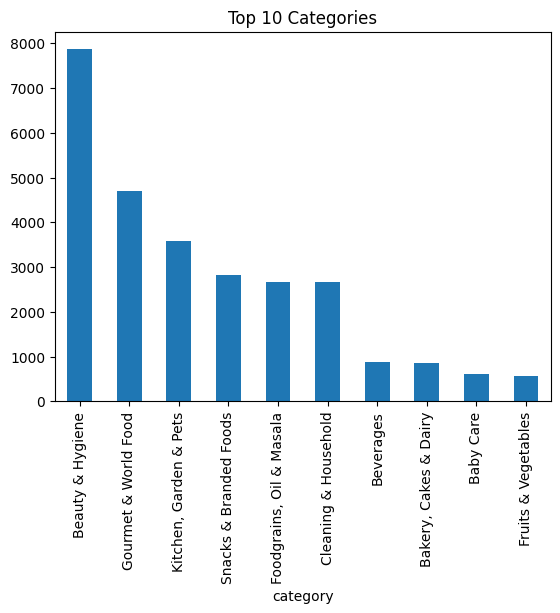

In [23]:
import matplotlib.pyplot as plt

df['category'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Categories")
plt.show()